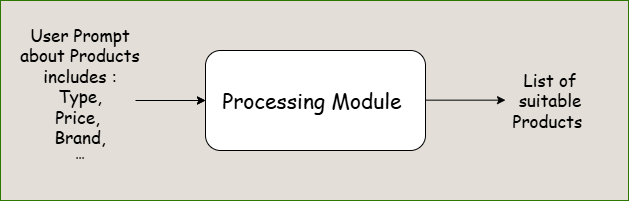

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
BASE = '/content/drive/MyDrive/digikala_project'

products = pd.read_csv(
    f'{BASE}/digikala-products.csv'
)

with open(
    f'{BASE}/query_understanding_results.json',
    'r',
    encoding='utf-8'
) as f:
    query_results = json.load(f)


# حذف محصولات تکراری بر اساس id
before = len(products)

products = (
    products
    .drop_duplicates(
        subset=['id'],
        keep='first'
    )
    .reset_index(drop=True)
)

after = len(products)


print(
    f"محصولات قبل از حذف تکراری: {before}"
)

print(
    f"محصولات بعد از حذف تکراری: {after}"
)

print(
    "درصد داده‌ی تکراری حذف‌شده: "
    f"{(before-after)/before*100:.1f}%"
)

/tmp/ipykernel_2688/1954418466.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  products = pd.read_csv(


محصولات قبل از حذف تکراری: 1283496
محصولات بعد از حذف تکراری: 948352
درصد داده‌ی تکراری حذف‌شده: 26.1%


In [3]:
# ======================================
# Data Preparation
# ======================================

products['Category2'] = products['Category2'].fillna('')

# میانگین امتیاز کل محصولات
C = products['Rate'].mean()

# فقط تعداد رأی‌های بزرگ‌تر از صفر
nonzero_votes = products.loc[
    products['Rate_cnt'] > 0,
    'Rate_cnt'
]

# Prior برای Bayesian Average
m = nonzero_votes.quantile(0.6)


def bayesian_score(row):
    v = row['Rate_cnt']
    R = row['Rate']

    return (
        (v / (v + m)) * R
        +
        (m / (v + m)) * C
    )


products['satisfaction_score'] = products.apply(
    bayesian_score,
    axis=1
)

products['satisfaction_norm'] = (
    products['satisfaction_score'] / 100
)


print("آماده‌سازی داده تمام شد.")
print("C =", C)
print("m =", m)

آماده‌سازی داده تمام شد.
C = 30.413787285733566
m = 6.0


In [4]:
# ======================================
# TF-IDF Baseline
# ======================================

import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ======================================
# 1) Build Search Text
# ======================================

products["search_text"] = (
    (products["title_fa"].astype(str) + " ") * 3
    +
    products["Category1"].astype(str) + " "
    +
    products["Category2"].astype(str) + " "
    +
    products["Brand"].fillna("").astype(str)
)


# ======================================
# 2) Build TF-IDF Index
# ======================================

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)


tfidf_matrix = vectorizer.fit_transform(
    products["search_text"]
)


print(
    "TF-IDF shape:",
    tfidf_matrix.shape
)


# ======================================
# 3) TF-IDF Search
# ======================================

def search_products_tfidf(
    query,
    price_max=None,
    brand=None,
    top_k=5
):

    # تبدیل Query به بردار TF-IDF
    query_vec = vectorizer.transform(
        [query]
    )


    # شباهت Query با تمام محصولات
    sim_scores = cosine_similarity(
        query_vec,
        tfidf_matrix
    ).flatten()


    result = products.copy()

    result["tfidf_score"] = sim_scores


    # ----------------------------------
    # Price Filter
    # ----------------------------------

    if price_max is not None:

        result = result[
            result["Price"] <= price_max
        ]


    # ----------------------------------
    # Brand Filter
    # ----------------------------------

    if brand:

        result = result[
            result["Brand"]
            .astype(str)
            .str.contains(
                brand,
                case=False,
                na=False
            )
        ]


    # فقط نتایجی که شباهت دارند
    result = result[
        result["tfidf_score"] > 0
    ]


    if result.empty:

        return pd.DataFrame()


    # ----------------------------------
    # Ranking
    # ----------------------------------

    result = result.sort_values(
        "tfidf_score",
        ascending=False
    )


    return result[
        [
            "id",
            "title_fa",
            "Brand",
            "Category1",
            "Category2",
            "Price",
            "Rate",
            "Rate_cnt",
            "tfidf_score"
        ]
    ].head(top_k)

TF-IDF shape: (948352, 50000)


# ⚓

# Retrieval Engine

In [5]:
# ======================================
# BM25 Index
# ======================================

!pip install -q rank_bm25

from rank_bm25 import BM25Okapi


persian_stopwords = {
    'و', 'در', 'به', 'از', 'که', 'این', 'را', 'با',
    'برای', 'است', 'یک', 'می', 'شود', 'های',
    'کرد', 'تا', 'یا'
}


def simple_tokenize(text):
    return [
        word
        for word in str(text).split()
        if word not in persian_stopwords
    ]


tokenized_corpus = [
    simple_tokenize(text)
    for text in products['search_text']
]


bm25 = BM25Okapi(
    tokenized_corpus
)


print("✅ BM25 index ساخته شد.")

✅ BM25 index ساخته شد.


In [15]:
# ======================================
# SBERT Product Embeddings
# ======================================

!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer, util
import torch
import os


device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)


# مدل SBERT
sbert_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2",
    device=device
)


# EMBEDDING_PATH = f"{BASE}/product_embeddings.pt"
EMBEDDING_PATH = f"{BASE}/product_embeddings_v2.pt"

# ======================================
# Load or Create Product Embeddings
# ======================================

if os.path.exists(EMBEDDING_PATH):

    product_embeddings = torch.load(
        EMBEDDING_PATH,
        map_location=device
    )

    print("✅ Product embeddings loaded from Drive.")


else:

    product_embeddings = sbert_model.encode(
        products["search_text"].tolist(),
        batch_size=256,
        show_progress_bar=True,
        convert_to_tensor=True,
        device=device
    )

    torch.save(
        product_embeddings,
        EMBEDDING_PATH
    )

    print("✅ Product embeddings created and saved.")


print(
    "Embedding shape:",
    product_embeddings.shape
)

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/3705 [00:00<?, ?it/s]

✅ Product embeddings created and saved.
Embedding shape: torch.Size([948352, 384])


Category Mapping Layer

In [16]:
# ======================================
# Category Embeddings
# ======================================

# ترکیب Category1 و Category2
unique_categories = (
    pd.concat([
        products["Category1"],
        products["Category2"]
    ])
    .dropna()
    .astype(str)
    .str.strip()
)

# حذف مقادیر خالی و تکراری
unique_categories = (
    unique_categories[
        unique_categories != ""
    ]
    .drop_duplicates()
    .tolist()
)


print(
    f"تعداد دسته‌بندی یکتا: {len(unique_categories)}"
)


# ساخت embedding برای نام دسته‌بندی‌ها
category_embeddings = sbert_model.encode(
    unique_categories,
    convert_to_tensor=True,
    device=device
)


print("✅ Category embeddings ساخته شد.")

تعداد دسته‌بندی یکتا: 828
✅ Category embeddings ساخته شد.


In [17]:
# ======================================
# Category Mapping
# ======================================

def map_product_type_to_category(
    product_type: str,
    top_n=3,
    min_category_similarity=0.35
):

    """
    Map LLM product_type to dataset taxonomy.

    Priority:
    1) Rule-based taxonomy mapping
    2) Semantic fallback using SBERT
    """

    if not product_type:
        return {
            "matched": False,
            "method": None,
            "candidates": []
        }


    text = str(product_type).lower().strip()


    # ======================================
    # 1) Manual taxonomy mapping
    # ======================================

    manual_mapping = {

        "لپ تاپ": [
            "لپ تاپ و نوت بوک"
        ],

        "لپ‌تاپ": [
            "لپ تاپ و نوت بوک"
        ],

        "گوشی": [
            "گوشی موبایل"
        ],

        "موبایل": [
            "گوشی موبایل"
        ],

        "کیف": [
            "کیف زنانه",
            "کیف زنانه و مردانه",
            "کیف مردانه",
            "کوله پشتی زنانه",
            "کوله پشتی زنانه و مردانه"
        ],

        "عطر": [
            "عطر و ادکلن زنانه",
            "عطر و ادکلن مردانه و زنانه",
            "ست عطر و ادکلن"
        ],

        "اسباب بازی": [
            "اسباب بازی",
            "فکری و آموزشی",
            "جغجغه، عروسک و مدل"
        ],

        "لباس ورزشی": [
            "لباس ورزشی مردانه",
            "لباس ورزشی زنانه"
        ]
    }


    for key, categories in manual_mapping.items():

        if key in text:

            # فقط دسته‌هایی که واقعاً در دیتاست وجود دارند
            valid_categories = [
                category
                for category in categories
                if category in unique_categories
            ]

            # if valid_categories:

            #     return {
            #         "matched": True,
            #         "method": "rule",
            #         "candidates": [
            #             (category, 1.0)
            #             for category in valid_categories
            #         ]
            #     }
            if valid_categories:

              return {
                  "matched": True,
                  "method": "rule",
                  "candidates": [
                      (category, 1.0)
                      for category in valid_categories]}

            else:

              return {
                  "matched": False,
                  "method": "rule_missing_in_dataset",
                  "candidates": []
              }


    # ======================================
    # 2) Semantic fallback
    # ======================================

    query_emb = sbert_model.encode(
        product_type,
        convert_to_tensor=True,
        device=device
    )


    similarities = util.cos_sim(
        query_emb,
        category_embeddings
    )[0].cpu().numpy()


    ranked_idx = (
        similarities
        .argsort()[::-1][:top_n]
    )


    matches = [
        (
            unique_categories[i],
            float(similarities[i])
        )
        for i in ranked_idx
    ]


    if not matches:

        return {
            "matched": False,
            "method": "embedding",
            "candidates": []
        }


    if matches[0][1] < min_category_similarity:

        return {
            "matched": False,
            "method": "embedding",
            "candidates": matches
        }


    return {
        "matched": True,
        "method": "embedding",
        "candidates": matches
    }

In [18]:
# ======================================
# Hybrid Retrieval Engine
# BM25 + SBERT + Satisfaction
# ======================================

def hybrid_search(
    structured_filter: dict,
    top_k=10,
    w_bm25=0.3,
    w_embedding=0.5,
    w_satisfaction=0.2,
    min_category_similarity=0.35
):

    # ======================================
    # 1) Read structured query
    # ======================================

    product_type = structured_filter.get("product_type")

    semantic_query = (
        structured_filter.get("semantic_query")
        or product_type
        or ""
    )

    price_max = structured_filter.get("price_max")
    price_min = structured_filter.get("price_min")

    exclude_fake = structured_filter.get(
        "exclude_fake",
        True
    )

    min_satisfaction = structured_filter.get(
        "min_satisfaction",
        False
    )


    # ======================================
    # 2) Start candidate set
    # ======================================

    df = products.copy()


    # ======================================
    # 3) Category Mapping
    # ======================================

    if product_type:

        cat_result = map_product_type_to_category(
            product_type,
            min_category_similarity=min_category_similarity
        )

        if not cat_result["matched"]:

            print(
                f"⚠️ هیچ دسته‌بندی مرتبط با "
                f"'{product_type}' پیدا نشد."
            )

            return pd.DataFrame()


        matched_categories = [
            category
            for category, score
            in cat_result["candidates"]
            if score >= min_category_similarity
        ]


        df = df[
            df["Category1"].isin(matched_categories)
            |
            df["Category2"].isin(matched_categories)
        ]


    # ======================================
    # 4) Hard Metadata Filtering
    # ======================================

    if exclude_fake:
        df = df[
            df["Is_Fake"] == False
        ]

    if price_max is not None:
        df = df[
            df["Price"] <= price_max
        ]

    if price_min is not None:
        df = df[
            df["Price"] >= price_min
        ]


    # ======================================
    # 5) Relaxed Retrieval Fallback
    # ======================================

    if df.empty or len(df) < top_k:

        print(
            "⚠️ Strict filtering produced too few "
            "candidates. Relaxing category filter..."
        )

        df = products.copy()


        # Category حذف می‌شود،
        # ولی constraintهای واقعی کاربر حفظ می‌شوند.

        if exclude_fake:
            df = df[
                df["Is_Fake"] == False
            ]

        if price_max is not None:
            df = df[
                df["Price"] <= price_max
            ]

        if price_min is not None:
            df = df[
                df["Price"] >= price_min
            ]


    if df.empty:
        return pd.DataFrame()


    # ======================================
    # 6) BM25 Score
    # ======================================

    idx = df.index

    tokenized_query = simple_tokenize(
        semantic_query
    )

    bm25_scores_full = bm25.get_scores(
        tokenized_query
    )

    bm25_scores = bm25_scores_full[idx]


    # Normalize BM25
    bm25_max = bm25_scores.max()

    if bm25_max > 0:

        bm25_scores_norm = (
            bm25_scores / bm25_max
        )

    else:

        bm25_scores_norm = bm25_scores


    # ======================================
    # 7) SBERT Semantic Score
    # ======================================

    query_embedding = sbert_model.encode(
        semantic_query,
        convert_to_tensor=True,
        device=device
    )


    embedding_scores_full = util.cos_sim(
        query_embedding,
        product_embeddings
    )[0].cpu().numpy()


    embedding_scores = (
        embedding_scores_full[idx]
    )


    # ======================================
    # 8) Add Scores
    # ======================================

    df = df.copy()

    df["bm25_score"] = (
        bm25_scores_norm
    )

    df["embedding_score"] = (
        embedding_scores
    )


    # ======================================
    # 9) Satisfaction Weight
    # ======================================

    if min_satisfaction:

        w_sat = (
            w_satisfaction * 1.5
        )

    else:

        w_sat = w_satisfaction


    # Normalize weights
    total_weight = (
        w_bm25
        + w_embedding
        + w_sat
    )


    # ======================================
    # 10) Final Hybrid Score
    # ======================================

    df["final_score"] = (

        w_bm25
        * df["bm25_score"]

        +

        w_embedding
        * df["embedding_score"]

        +

        w_sat
        * df["satisfaction_norm"]

    ) / total_weight


    # ======================================
    # 11) Final Ranking
    # ======================================

    result = (
        df
        .sort_values(
            "final_score",
            ascending=False
        )
        .head(top_k)
    )


    return result[
        [
            "id",
            "title_fa",
            "Category1",
            "Category2",
            "Price",
            "Rate",
            "Rate_cnt",
            "bm25_score",
            "embedding_score",
            "satisfaction_norm",
            "final_score"
        ]
    ]

In [19]:
# ======================================
# End-to-End Retrieval Test
# ======================================

for item in query_results:

    if not item["success"]:
        continue

    print("\n" + "=" * 60)
    print(f"🔍 پرسش کاربر: {item['query']}")
    print(f"📋 فیلتر استخراج‌شده: {item['output']}")
    print("-" * 60)

    result = hybrid_search(
        item["output"],
        top_k=5
    )

    if result.empty:

        print(
            "⚠️ هیچ محصولی با این فیلترها پیدا نشد."
        )

    else:

        print(
            result[
                [
                    "title_fa",
                    "Price",
                    "Rate",
                    "bm25_score",
                    "embedding_score",
                    "final_score"
                ]
            ].to_string(index=False)
        )


🔍 پرسش کاربر: یک کیف دستی زنانه میخوام که ارزون باشه
📋 فیلتر استخراج‌شده: {'product_type': 'کیف دستی زنانه', 'price_max': 1000000, 'price_min': None, 'min_satisfaction': False, 'exclude_fake': True, 'semantic_query': 'کیف دستی زنانه ارزان'}
------------------------------------------------------------
                       title_fa  Price  Rate  bm25_score  embedding_score  final_score
        کیف دستی زنانه مدل 0044 350000    82    1.000000         0.672751     0.799723
        کیف دستی زنانه مدل قلبی 990000    78    1.000000         0.557339     0.730863
               کیف دستی مدل TGR 150000    68    0.981743         0.592970     0.714479
کیف دستی زنانه کد TRJ-DLT-B1131 590000    66    1.000000         0.555223     0.701399
        کیف دستی زنانه مدل SAGG 989900    72    1.000000         0.584126     0.690696

🔍 پرسش کاربر: لپ‌تاپ خوب زیر ۵۰ میلیون معرفی کن
📋 فیلتر استخراج‌شده: {'product_type': 'لپ\u200cتاپ', 'price_max': 50000000, 'price_min': None, 'min_satisfaction': False, 'exc

In [21]:
# سلول: اجرای همه‌ی query‌ها و ذخیره‌ی نتایج retrieval (بدون LLM response هنوز)
retrieval_outputs = []

for item in query_results:
    if not item['success']:
        continue
    result = hybrid_search(item['output'], top_k=5)
    retrieval_outputs.append({
        "user_query": item['query'],
        "structured_filter": item['output'],
        "retrieved_products": result.to_dict(orient='records') if not result.empty else []
    })

with open(f'{BASE}/retrieval_results.json', 'w', encoding='utf-8') as f:
    json.dump(retrieval_outputs, f, ensure_ascii=False, indent=2)

print("ذخیره شد در Drive: retrieval_results.json")

⚠️ هیچ دسته‌بندی مرتبط با 'لپ‌تاپ' پیدا نشد.
⚠️ هیچ دسته‌بندی مرتبط با 'گوشی موبایل' پیدا نشد.
ذخیره شد در Drive: retrieval_results.json
